In [13]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. ตั้งค่าพารามิเตอร์พื้นฐาน
# ==========================================
np.random.seed(42)       # ล็อก seed เพื่อให้ผลลัพธ์เหมือนเดิมทุกครั้ง
n_trials = 10000         # จำนวนครั้งที่จำลองการทอย (จำนวน Sample)
n_dice_list = [1, 2, 3, 5, 10, 100]  # ขนาดของกลุ่มตัวอย่าง (จำนวนลูกเต๋า n)

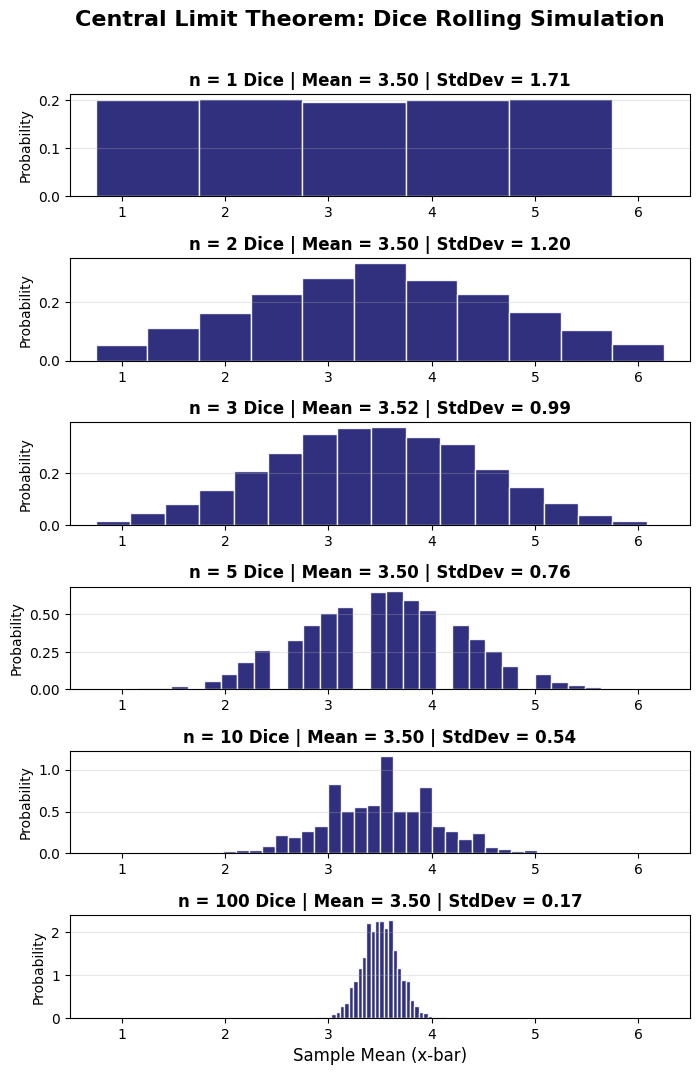

In [14]:
# สร้างพื้นที่วาดกราฟแบบหลายชั้น (5 แถว 1 คอลัมน์)
fig, axes = plt.subplots(len(n_dice_list), 1, figsize=(8, 12))
plt.subplots_adjust(hspace=0.6) # เพิ่มช่องว่างระหว่างกราฟ

# ==========================================
# 2. เริ่มการจำลองและพล็อตกราฟ
# ==========================================
for i, n in enumerate(n_dice_list):
    # สุ่มทอยลูกเต๋า (ค่า 1 ถึง 6) จำนวน n ลูก เป็นเวลา n_trials ครั้ง
    # จะได้ Array ขนาด (10000, n)
    rolls = np.random.randint(1, 7, size=(n_trials, n))

    # หาค่าเฉลี่ยของการทอยในแต่ละครั้ง (แกน X-bar)
    sample_means = np.mean(rolls, axis=1)

    # คำนวณ Mean และ Standard Deviation ของ Sample Means เพื่อแสดงบนกราฟ
    actual_mean = np.mean(sample_means)
    actual_std = np.std(sample_means)

    # พล็อตกราฟ Histogram
    # หาก n น้อย เราจะแบ่ง bins ให้กว้างหน่อยเพื่อให้กราฟดูสวยงามแบบก้อนๆ ตามสไลด์
    bins = 30 if n >= 5 else np.arange(0.75, 6.75, 1/n)

    axes[i].hist(sample_means, bins=bins, density=True, color='midnightblue', edgecolor='white', alpha=0.9)

    # ตกแต่งกราฟให้สวยงามและอ่านง่าย
    axes[i].set_title(f'n = {n} Dice | Mean = {actual_mean:.2f} | StdDev = {actual_std:.2f}', fontsize=12, fontweight='bold')
    axes[i].set_xlim(0.5, 6.5)
    axes[i].set_ylabel('Probability')
    axes[i].grid(axis='y', alpha=0.3)

# ใส่ชื่อแกน X ที่กราฟรูปล่างสุด
axes[-1].set_xlabel('Sample Mean (x-bar)', fontsize=12)

# ==========================================
# 3. บันทึกและแสดงผล
# ==========================================
plt.suptitle('Central Limit Theorem: Dice Rolling Simulation', fontsize=16, fontweight='bold', y=0.95)
plt.savefig('clt_simulation.png', dpi=150, bbox_inches='tight')
plt.show()